In [1]:
%%capture

import os
os.environ["USE_TF"] = "0"

from collections import defaultdict
import pandas as pd
from seqeval.metrics import f1_score
from transformers import DataCollatorForTokenClassification
from transformers import Trainer
from transformers import TrainingArguments
import import_ipynb
from a_glance_at_dataset_and_tokenizer import panx_ch, tags, xlmr_tokenizer
from create_model import device, tag_text, XLMRobertaForTokenClassification, xlmr_config
from performance_measures import align_predictions
from tokenizing_text import encode_panx_dataset, panx_de_encoded

In [3]:
import gc
import torch
import create_model

if hasattr(create_model, "outputs"):
    del create_model.outputs

if hasattr(create_model, "xlmr_model"):
    del create_model.xlmr_model

gc.collect()
torch.cuda.empty_cache()

print(
    "allocated:",
    torch.cuda.memory_allocated() / 1024**3,
    "GB"
)

allocated: 0.007935047149658203 GB


In [4]:
num_epochs = 3
batch_size = 24
xlmr_model_name = "xlm-roberta-base"
model_name = f"{xlmr_model_name}-finetuned-panx-de"

In [5]:
def compute_metrics(eval_pred):
    y_pred, y_true = align_predictions(eval_pred.predictions, eval_pred.label_ids)

    return {"f1": f1_score(y_true, y_pred)}

In [27]:
model = XLMRobertaForTokenClassification.from_pretrained(
    model_name
).to(device)

In [13]:
data_collator = DataCollatorForTokenClassification(xlmr_tokenizer)

In [28]:
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=xlmr_tokenizer,
)

In [29]:
def get_f1_score(trainer, dataset):
    return trainer.predict(dataset).metrics["test_f1"]

In [32]:
f1_scores = defaultdict(dict)
f1_scores["de"]["de"] = get_f1_score(trainer, panx_de_encoded["test"])
print(f"F1 score of [de] model on [de] dataset: {f1_scores['de']['de']:.3f}")

F1 score of [de] model on [de] dataset: 0.866


In [34]:
text_fr = "Jeff Dean est informaticien chez Google en Californie"
tag_text(text_fr, tags, trainer.model, xlmr_tokenizer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Tokens,<s>,▁Jeff,▁De,an,▁est,▁informatic,ien,▁chez,▁Google,▁en,▁Cali,for,nie,</s>
Tags,O,B-PER,I-PER,I-PER,O,O,O,O,B-ORG,O,B-LOC,I-LOC,I-LOC,O


In [30]:
def evaluate_lang_performance(lang, trainer):
    panx_ds = encode_panx_dataset(panx_ch[lang])
    return get_f1_score(trainer, panx_ds["test"])

In [33]:
f1_scores["de"]["fr"] = evaluate_lang_performance("fr", trainer)
print(f"F1-score of [de] model on [fr] dataset: {f1_scores['de']['fr']:.3f}")

F1-score of [de] model on [fr] dataset: 0.690


In [39]:
f1_scores["de"]["it"] = evaluate_lang_performance("it", trainer)
print(f"F1-score of [de] model on [it] dataset: {f1_scores['de']['it']:.3f}")

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

F1-score of [de] model on [it] dataset: 0.688


In [40]:
f1_scores["de"]["en"] = evaluate_lang_performance("en", trainer)
print(f"F1-score of [de] model on [en] dataset: {f1_scores['de']['en']:.3f}")

Map:   0%|          | 0/1180 [00:00<?, ? examples/s]

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

Map:   0%|          | 0/590 [00:00<?, ? examples/s]

F1-score of [de] model on [en] dataset: 0.582


In [18]:
def model_init():
    return (XLMRobertaForTokenClassification
           .from_pretrained(xlmr_model_name, config=xlmr_config)
           .to(device))

In [19]:
training_args = TrainingArguments(
    output_dir=model_name, log_level="error", num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_gpu_eval_batch_size=batch_size, eval_strategy="epoch",
    save_steps=1e6, weight_decay=0.01, disable_tqdm=False,
    push_to_hub=False,
)

In [20]:
def train_on_subset(dataset, num_samples):
    train_ds = dataset['train'].shuffle(seed=42).select(range(num_samples))
    val_ds = dataset['validation']
    test_ds = dataset['test']
    training_args.logging_steps = len(train_ds) // batch_size
    trainer = Trainer(model_init=model_init, args=training_args,
        data_collator=data_collator, compute_metrics=compute_metrics, 
        train_dataset=train_ds, eval_dataset=val_ds, processing_class=xlmr_tokenizer,
    )
    trainer.train()

    if training_args.push_to_hub:
        trainer.push_to_hub(commit_message="Training Completed!")

    f1_score = get_f1_score(trainer, test_ds)
    return pd.DataFrame.from_dict(
        {"num_samples": [len(train_ds)], "f1_score": [f1_score]}
    )

In [21]:
panx_fr_encoded = encode_panx_dataset(panx_ch['fr'])
training_args.push_to_hub = False
metrics_df = train_on_subset(panx_fr_encoded, 250)
metrics_df

Epoch,Training Loss,Validation Loss,F1
1,1.594400,1.286918,0.000670
2,1.209200,0.976072,0.194028
3,0.950400,0.847744,0.363770


,num_samples,f1_score
0,250,0.356663


In [23]:
for num_samples in [500, 1000, 2000, 4000]:
    metrics_df = pd.concat(
        [metrics_df, train_on_subset(panx_fr_encoded, num_samples)], 
        ignore_index=True
    )

Epoch,Training Loss,Validation Loss,F1
1,1.371200,0.920799,0.400664
2,0.762800,0.577416,0.635390
3,0.486900,0.489843,0.700596


Epoch,Training Loss,Validation Loss,F1
1,1.040600,0.514987,0.689932
2,0.450700,0.405170,0.717479
3,0.288800,0.369135,0.773864


Epoch,Training Loss,Validation Loss,F1
1,0.748000,0.392364,0.752353
2,0.319000,0.358017,0.770826
3,0.212500,0.333133,0.813304


Epoch,Training Loss,Validation Loss,F1
1,0.560200,0.355590,0.786977
2,0.268300,0.279027,0.830069
3,0.179800,0.271160,0.838364


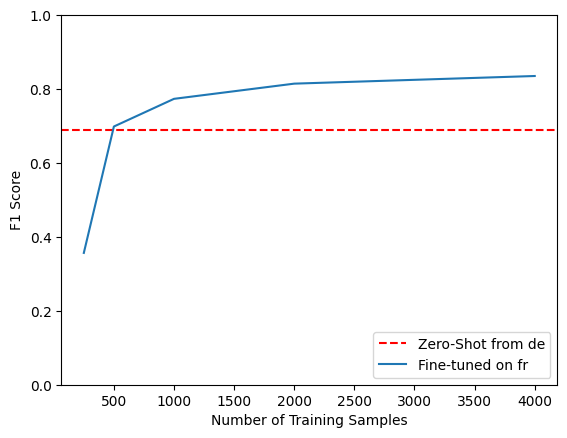

In [36]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots()
ax.axhline(f1_scores["de"]["fr"], ls="--", color="r")
metrics_df.set_index("num_samples").plot(ax=ax)
plt.legend(["Zero-Shot from de", "Fine-tuned on fr"], loc="lower right")
plt.ylim((0, 1))
plt.xlabel("Number of Training Samples")
plt.ylabel("F1 Score")
plt.show()